Imported appropriate libraries to start analysis and create visualizations

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f"{x:,.2f}")

sns.set(style='whitegrid')

Uploaded the below CSV file to extract the data

In [65]:
df = pd.read_csv('https://raw.githubusercontent.com/amohanlall/my_vision/refs/heads/main/social_media_mental_health.csv')



Examined column names and data samples to get a general sense of the statistics for analysis

In [66]:

print('Shape (rows, columns):', df.shape)

print('\nColumn names:')
print(df.columns)

print('\nData types and non-null counts:')
df.info()

print('\nSummary statistics (numeric columns):')
df.describe()

Shape (rows, columns): (8000, 15)

Column names:
Index(['User_ID', 'Age', 'Gender', 'User_Archetype', 'Primary_Platform',
       'Daily_Screen_Time_Hours', 'Dominant_Content_Type', 'Activity_Type',
       'Late_Night_Usage', 'Social_Comparison_Trigger', 'Sleep_Duration_Hours',
       'GAD_7_Score', 'GAD_7_Severity', 'PHQ_9_Score', 'PHQ_9_Severity'],
      dtype='object')

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   User_ID                    8000 non-null   object 
 1   Age                        8000 non-null   int64  
 2   Gender                     8000 non-null   object 
 3   User_Archetype             8000 non-null   object 
 4   Primary_Platform           8000 non-null   object 
 5   Daily_Screen_Time_Hours    8000 non-null   float64
 6   Dominant_Content_Type      8000 n

,Age,Daily_Screen_Time_Hours,Late_Night_Usage,Social_Comparison_Trigger,Sleep_Duration_Hours,GAD_7_Score,PHQ_9_Score
count,"8,000.00","8,000.00","8,000.00","8,000.00","8,000.00","8,000.00","8,000.00"
mean,19.06,4.28,0.38,0.10,5.80,7.35,5.38
std,1.12,2.31,0.49,0.30,1.34,4.63,4.82
min,18.00,0.50,0.00,0.00,3.00,0.00,0.00
25%,18.00,2.42,0.00,0.00,4.80,4.00,1.00
50%,19.00,4.27,0.00,0.00,5.80,7.00,5.00
75%,20.00,6.05,1.00,0.00,6.80,11.00,9.00
max,22.00,11.31,1.00,1.00,11.60,21.00,23.00


Displayed the first 10 rows to better understand the dataset structure and determine which variables to analyze and compare

In [67]:
# First 10 rows
df.head(10)

,User_ID,Age,Gender,User_Archetype,Primary_Platform,Daily_Screen_Time_Hours,Dominant_Content_Type,Activity_Type,Late_Night_Usage,Social_Comparison_Trigger,Sleep_Duration_Hours,GAD_7_Score,GAD_7_Severity,PHQ_9_Score,PHQ_9_Severity
0,U-b23639d2,18,Male,Hyper-Connected,Twitter/X,8.50,Gaming,Active,0,0,3.90,9,Mild,5,Mild
1,U-e7778765,20,Male,Digital Minimalist,TikTok,0.50,Gaming,Active,0,0,5.50,0,Minimal,8,Mild
2,U-76749892,18,Female,Digital Minimalist,Snapchat,0.91,Gaming,Active,0,0,8.90,1,Minimal,3,None-Minimal
3,U-dcbbd7f9,18,Female,Hyper-Connected,Snapchat,7.43,Gaming,Active,1,0,6.20,13,Moderate,0,None-Minimal
4,U-9e1ba278,18,Male,Hyper-Connected,LinkedIn,4.94,Entertainment/Comedy,Active,1,0,5.30,13,Moderate,10,Moderate
5,U-e578c94a,18,Male,Digital Minimalist,YouTube,0.56,Entertainment/Comedy,Active,0,0,6.20,0,Minimal,2,None-Minimal
6,U-a04da6a8,20,Female,Hyper-Connected,Facebook,6.57,Lifestyle/Fashion,Active,1,0,4.70,15,Severe,12,Moderate
7,U-408fc499,18,Female,Hyper-Connected,Twitter/X,7.18,Lifestyle/Fashion,Active,0,0,4.80,6,Mild,5,Mild
8,U-90ce461c,18,Male,Passive Scroller,Facebook,3.41,Lifestyle/Fashion,Passive,0,0,7.00,5,Mild,4,None-Minimal
9,U-ee0c9c9b,20,Male,Average User,LinkedIn,1.97,Gaming,Active,0,0,4.60,5,Mild,3,None-Minimal


Pulled a random 5 samples of data to identify any missing values

In [68]:
# Random sample of 5 rows
df.sample(5, random_state=42)

,User_ID,Age,Gender,User_Archetype,Primary_Platform,Daily_Screen_Time_Hours,Dominant_Content_Type,Activity_Type,Late_Night_Usage,Social_Comparison_Trigger,Sleep_Duration_Hours,GAD_7_Score,GAD_7_Severity,PHQ_9_Score,PHQ_9_Severity
2215,U-3dab0cc7,19,Male,Digital Minimalist,TikTok,0.50,Lifestyle/Fashion,Active,0,1,6.00,7,Mild,1,None-Minimal
2582,U-7e67ee9b,18,Female,Passive Scroller,YouTube,5.38,Self-Help/Motivation,Passive,0,0,6.20,12,Moderate,2,None-Minimal
1662,U-087e488b,18,Female,Average User,TikTok,5.02,Self-Help/Motivation,Active,1,1,6.10,15,Severe,12,Moderate
3027,U-04d14d62,18,Male,Hyper-Connected,LinkedIn,7.51,Lifestyle/Fashion,Active,0,0,4.70,2,Minimal,4,None-Minimal
4343,U-833f4a92,18,Male,Passive Scroller,LinkedIn,3.70,News/Politics,Passive,0,0,6.30,9,Mild,5,Mild


Generating summary statistics helps identify potential data quality issues such as missing values, outliers, or skewed distributions. It also provides insight into whether the data requires cleaning or transformation.

In [69]:
# Summary statistics for all columns (numeric + non-numeric)
df.describe(include='all')

,User_ID,Age,Gender,User_Archetype,Primary_Platform,Daily_Screen_Time_Hours,Dominant_Content_Type,Activity_Type,Late_Night_Usage,Social_Comparison_Trigger,Sleep_Duration_Hours,GAD_7_Score,GAD_7_Severity,PHQ_9_Score,PHQ_9_Severity
count,8000,"8,000.00",8000,8000,8000,"8,000.00",8000,8000,"8,000.00","8,000.00","8,000.00","8,000.00",8000,"8,000.00",8000
unique,8000,NaN,2,4,7,NaN,6,2,NaN,NaN,NaN,NaN,4,NaN,5
top,U-ec5fac94,NaN,Female,Hyper-Connected,TikTok,NaN,Lifestyle/Fashion,Active,NaN,NaN,NaN,NaN,Mild,NaN,None-Minimal
freq,1,NaN,4028,2068,1185,NaN,1387,6091,NaN,NaN,NaN,NaN,2891,NaN,3966
mean,NaN,19.06,NaN,NaN,NaN,4.28,NaN,NaN,0.38,0.10,5.80,7.35,NaN,5.38,NaN
std,NaN,1.12,NaN,NaN,NaN,2.31,NaN,NaN,0.49,0.30,1.34,4.63,NaN,4.82,NaN
min,NaN,18.00,NaN,NaN,NaN,0.50,NaN,NaN,0.00,0.00,3.00,0.00,NaN,0.00,NaN
25%,NaN,18.00,NaN,NaN,NaN,2.42,NaN,NaN,0.00,0.00,4.80,4.00,NaN,1.00,NaN
50%,NaN,19.00,NaN,NaN,NaN,4.27,NaN,NaN,0.00,0.00,5.80,7.00,NaN,5.00,NaN
75%,NaN,20.00,NaN,NaN,NaN,6.05,NaN,NaN,1.00,0.00,6.80,11.00,NaN,9.00,NaN


Retrieved the last 10 rows of data to review the most recent observations and verify if any records contain missing values.

In [70]:
df.tail(10)

,User_ID,Age,Gender,User_Archetype,Primary_Platform,Daily_Screen_Time_Hours,Dominant_Content_Type,Activity_Type,Late_Night_Usage,Social_Comparison_Trigger,Sleep_Duration_Hours,GAD_7_Score,GAD_7_Severity,PHQ_9_Score,PHQ_9_Severity
7990,U-f05625dc,19,Male,Average User,TikTok,5.71,News/Politics,Active,0,0,4.70,4,Minimal,5,Mild
7991,U-4fcf58f0,18,Female,Passive Scroller,YouTube,4.36,Gaming,Passive,1,0,4.30,12,Moderate,9,Mild
7992,U-645cea19,19,Female,Digital Minimalist,Instagram,1.91,Gaming,Active,0,0,6.70,3,Minimal,0,None-Minimal
7993,U-34e93bc1,22,Male,Passive Scroller,LinkedIn,4.07,Educational/Tech,Passive,1,0,5.30,10,Moderate,7,Mild
7994,U-ded36933,19,Female,Hyper-Connected,YouTube,6.51,News/Politics,Active,1,0,3.70,15,Severe,8,Mild
7995,U-d426a474,21,Female,Hyper-Connected,TikTok,5.62,Gaming,Active,1,0,5.70,6,Mild,10,Moderate
7996,U-d96fd8b6,18,Male,Digital Minimalist,YouTube,3.15,News/Politics,Active,0,0,6.30,0,Minimal,12,Moderate
7997,U-d3fdaa9b,18,Male,Hyper-Connected,YouTube,7.47,Gaming,Active,1,0,6.10,12,Moderate,14,Moderate
7998,U-128befb0,18,Female,Hyper-Connected,Instagram,8.45,Self-Help/Motivation,Active,0,1,4.30,11,Moderate,2,None-Minimal
7999,U-2d834d22,19,Male,Digital Minimalist,Twitter/X,0.80,News/Politics,Active,0,0,7.20,8,Mild,0,None-Minimal


Identified missing data and assessed the number of unique values in each column to better understand the dataset structure. Within the dataset there were no identified missing values

In [71]:
print('Missing values per column:')
print(df.isna().sum())

print('\nPercentage of missing values per column:')
print((df.isna().mean() * 100).round(2))

print('\nNumber of unique values per column:')
print(df.nunique())

Missing values per column:
User_ID                      0
Age                          0
Gender                       0
User_Archetype               0
Primary_Platform             0
Daily_Screen_Time_Hours      0
Dominant_Content_Type        0
Activity_Type                0
Late_Night_Usage             0
Social_Comparison_Trigger    0
Sleep_Duration_Hours         0
GAD_7_Score                  0
GAD_7_Severity               0
PHQ_9_Score                  0
PHQ_9_Severity               0
dtype: int64

Percentage of missing values per column:
User_ID                     0.00
Age                         0.00
Gender                      0.00
User_Archetype              0.00
Primary_Platform            0.00
Daily_Screen_Time_Hours     0.00
Dominant_Content_Type       0.00
Activity_Type               0.00
Late_Night_Usage            0.00
Social_Comparison_Trigger   0.00
Sleep_Duration_Hours        0.00
GAD_7_Score                 0.00
GAD_7_Severity              0.00
PHQ_9_Score             

Normalized column names for uniformity, improving clarity and analytical accuracy

In [72]:
# 1. Clean column names
df.columns = (
    df.columns
      .str.lower()

)
df.columns


Index(['user_id', 'age', 'gender', 'user_archetype', 'primary_platform',
       'daily_screen_time_hours', 'dominant_content_type', 'activity_type',
       'late_night_usage', 'social_comparison_trigger', 'sleep_duration_hours',
       'gad_7_score', 'gad_7_severity', 'phq_9_score', 'phq_9_severity'],
      dtype='object')

Inpected the unique values in the daily_screen_time_hours to idenify what type of data we would be working with


In [73]:
# Inspect unique values in daily_screen_time_hours
df['daily_screen_time_hours'].unique()[:10]

array([8.5 , 0.5 , 0.91, 7.43, 4.94, 0.56, 6.57, 7.18, 3.41, 1.97])

The below syntax forces several columns to become numeric, even if they currently contain strings, mixed types, or invalid characters

In [74]:
cols = ['age','daily_screen_time_hours','late_night_usage', 'social_comparison_trigger', 'sleep_duration_hours',
       'gad_7_score','phq_9_score']

df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')



used df.insa().sum() to identify and confirm that there are no missing values


In [75]:
# Check missing values
df.isna().sum()

,0
user_id,0
age,0
gender,0
user_archetype,0
primary_platform,0
daily_screen_time_hours,0
dominant_content_type,0
activity_type,0
late_night_usage,0
social_comparison_trigger,0


Converting columns to categorical data type

In [76]:

categorical_cols = [
    'user_id', 'gender', 'user_archetype', 'primary_platform',
    'dominant_content_type', 'activity_type', 'social_comparison_trigger',
    'gad_7_severity','phq_9_severity']

for col in categorical_cols:
    df[col] = df[col].astype('category')

df[categorical_cols].dtypes

,0
user_id,category
gender,category
user_archetype,category
primary_platform,category
dominant_content_type,category
activity_type,category
social_comparison_trigger,category
gad_7_severity,category
phq_9_severity,category


Extracted data categories containing numerical types (such as integers and floats) to gain a comprehensive overview of the data for modeling. This provides a statistical summary that highlights the distribution of the numerical variables

In [77]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
numeric_df.describe()

,age,daily_screen_time_hours,late_night_usage,sleep_duration_hours,gad_7_score,phq_9_score
count,"8,000.00","8,000.00","8,000.00","8,000.00","8,000.00","8,000.00"
mean,19.06,4.28,0.38,5.80,7.35,5.38
std,1.12,2.31,0.49,1.34,4.63,4.82
min,18.00,0.50,0.00,3.00,0.00,0.00
25%,18.00,2.42,0.00,4.80,4.00,1.00
50%,19.00,4.27,0.00,5.80,7.00,5.00
75%,20.00,6.05,1.00,6.80,11.00,9.00
max,22.00,11.31,1.00,11.60,21.00,23.00


This code generates charts to visualize the distribution of variables within the dataset and also provides a numerical summary for the selected categories

In [78]:
print('age:')
print(df['age'].describe())

print('\ndaily_screen_time_hours:')
print(df['daily_screen_time_hours'].describe())

print('\nsleep_duration_hours:')
print(df['sleep_duration_hours'].describe())

print('\ngad_7_score:')
print(df['gad_7_score'].describe())

print('\nphq_9_score:')
print(df['phq_9_score'].describe())

print('\ngender:')
print(df['gender'].describe())



age:
count   8,000.00
mean       19.06
std         1.12
min        18.00
25%        18.00
50%        19.00
75%        20.00
max        22.00
Name: age, dtype: float64

daily_screen_time_hours:
count   8,000.00
mean        4.28
std         2.31
min         0.50
25%         2.42
50%         4.27
75%         6.05
max        11.31
Name: daily_screen_time_hours, dtype: float64

sleep_duration_hours:
count   8,000.00
mean        5.80
std         1.34
min         3.00
25%         4.80
50%         5.80
75%         6.80
max        11.60
Name: sleep_duration_hours, dtype: float64

gad_7_score:
count   8,000.00
mean        7.35
std         4.63
min         0.00
25%         4.00
50%         7.00
75%        11.00
max        21.00
Name: gad_7_score, dtype: float64

phq_9_score:
count   8,000.00
mean        5.38
std         4.82
min         0.00
25%         1.00
50%         5.00
75%         9.00
max        23.00
Name: phq_9_score, dtype: float64

gender:
count       8000
unique         2
top       Fe

I used the following syntax to identify the top 10 pieces of data reported by users. This allowed me to filter the dataset and focus my analysis on the most relevant entries, making it easier to create clean, targeted visualizations and gain clearer insights into the relationships between platform usage, sleep patterns, and mental health indicators

In [79]:

top10_causes = (
    df.groupby('primary_platform')['sleep_duration_hours']
      .sum()
      .nlargest(10)
      .index
)


df_top10 = df[df['primary_platform'].isin(top10_causes)].copy()
df_top10['primary_platform'] = pd.Categorical(df_top10['primary_platform'], categories=top10_causes, ordered=True)

df_top10[['primary_platform', 'gender', 'sleep_duration_hours', 'gad_7_score', 'phq_9_score', 'daily_screen_time_hours', 'dominant_content_type']].head(10)

/tmp/ipython-input-2640066249.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('primary_platform')['sleep_duration_hours']


,primary_platform,gender,sleep_duration_hours,gad_7_score,phq_9_score,daily_screen_time_hours,dominant_content_type
0,Twitter/X,Male,3.90,9,5,8.50,Gaming
1,TikTok,Male,5.50,0,8,0.50,Gaming
2,Snapchat,Female,8.90,1,3,0.91,Gaming
3,Snapchat,Female,6.20,13,0,7.43,Gaming
4,LinkedIn,Male,5.30,13,10,4.94,Entertainment/Comedy
5,YouTube,Male,6.20,0,2,0.56,Entertainment/Comedy
6,Facebook,Female,4.70,15,12,6.57,Lifestyle/Fashion
7,Twitter/X,Female,4.80,6,5,7.18,Lifestyle/Fashion
8,Facebook,Male,7.00,5,4,3.41,Lifestyle/Fashion
9,LinkedIn,Male,4.60,5,3,1.97,Gaming


I categorized the sleep duration data into groups to improve the clarity of my analysis. Using predefined numeric ranges, I assigned each participant to a labeled sleep category such as “4–6 hrs” or “6–8 hrs.” This transformation created a new variable, sleep group, which makes it easier to compare trends across different levels of sleep. By converting raw hour values into interpretable categories, the dataset becomes more suitable for visual summaries and grouped statistical analysis. This step enhances the overall readability and analytical depth of the project.

In [80]:
sleep_bins = [0, 4, 6, 8, 10, 24]
sleep_labels = ['<4 hrs', '4–6 hrs', '6–8 hrs', '8–10 hrs', '>10 hrs']

df['sleep_group'] = pd.cut(
    df['sleep_duration_hours'],
    bins=sleep_bins,
    labels=sleep_labels
)


First we calculate the average GAD-7 and PHQ-9 scores for each combination of sleep group and gender using groupby () and mean(). It then reshapes the summary data into long format using melt() so that both scores can be plotted side by side. This setup makes it easy to compare how mental health scores vary by sleep duration and gender

/tmp/ipython-input-903697639.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby(['sleep_group', 'gender'])[['phq_9_score', 'gad_7_score']].mean().reset_index()


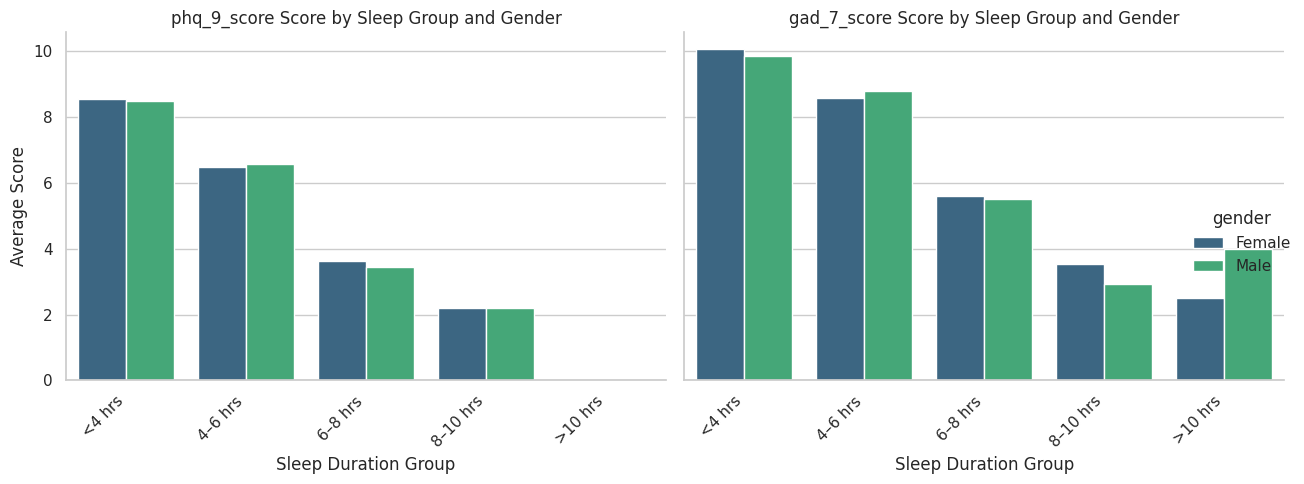

In [81]:

summary = df.groupby(['sleep_group', 'gender'])[['phq_9_score', 'gad_7_score']].mean().reset_index()

summary_melted = summary.melt(id_vars=['sleep_group', 'gender'], var_name='Score_Type', value_name='Average_Score')

g = sns.catplot(
    data=summary_melted,
    x='sleep_group',
    y='Average_Score',
    hue='gender',
    col='Score_Type',
    kind='bar',
    palette='viridis',
    height=5, aspect=1.2
)
g.set_axis_labels("Sleep Duration Group", "Average Score")
g.set_titles("{col_name} Score by Sleep Group and Gender")
g.set_xticklabels(rotation=45, ha='right')
plt.tight_layout()
plt.show()

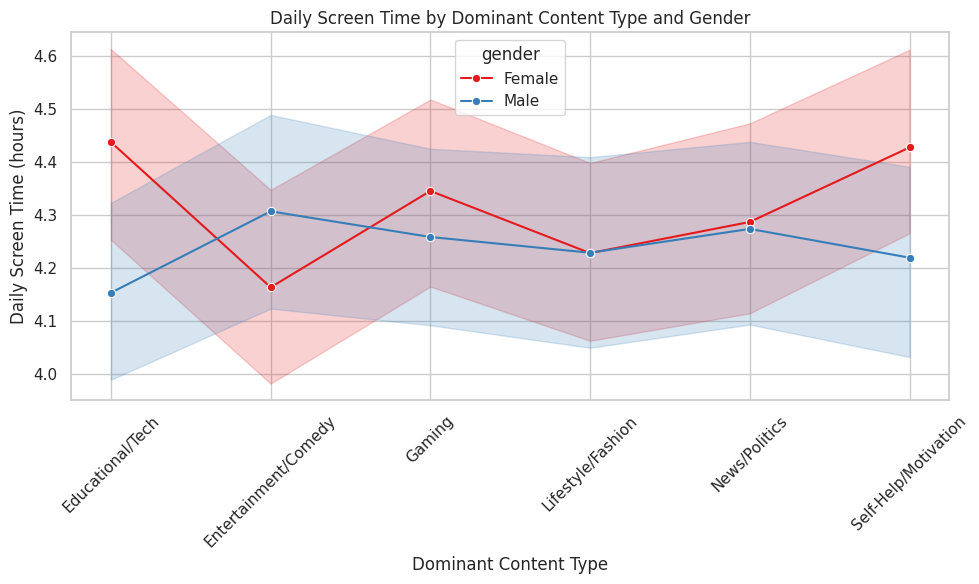

In [82]:
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.lineplot(data=df, x="dominant_content_type", y="daily_screen_time_hours", hue="gender", palette="Set1", marker='o')
plt.title("Daily Screen Time by Dominant Content Type and Gender")
plt.xlabel("Dominant Content Type")
plt.ylabel("Daily Screen Time (hours)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

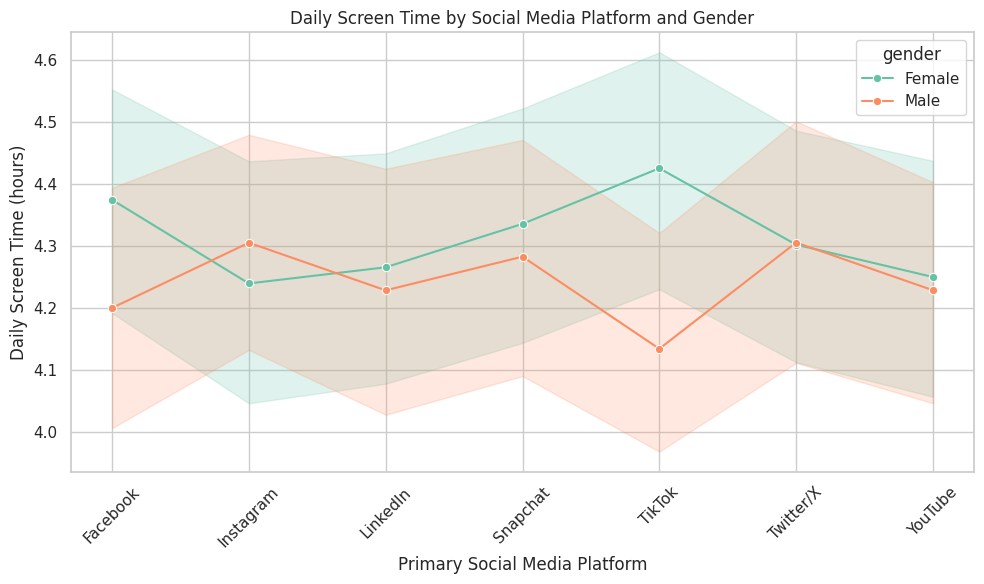

In [83]:
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.lineplot(data=df, x="primary_platform", y="daily_screen_time_hours", hue="gender", palette="Set2", marker='o')
plt.title("Daily Screen Time by Social Media Platform and Gender")
plt.xlabel("Primary Social Media Platform")
plt.ylabel("Daily Screen Time (hours)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Based on the analysis and visualizations, individuals who sleep less than six hours tend to have higher PHQ-9 scores. The PHQ-9 is a screening tool commonly used to assess symptoms of depression and other mental health conditions. These elevated PHQ scores closely align with higher GAD-7 scores, which measure symptoms of generalized anxiety disorder. The data suggests a clear association between reduced sleep duration and increased indicators of both depression and anxiety. This pattern is consistent across gender groups and highlights the importance of sleep in mental health outcomes.

The analysis also shows that females tend to have higher overall screen time on social media compared to males. Female participants are more active on platforms such as TikTok and Facebook, whereas males more commonly use Instagram and Twitter/X, but with noticeably lower screen time. Content preferences also differ: females engage more with educational, technology related, and self‑help or motivational material content often associated with managing anxiety, depression, or personal growth. In contrast, males gravitate toward comedy, entertainment, and lifestyle or fashion content. Overall, the data indicates that men spend less time on social media than women.


In [84]:
df.describe()
df.groupby('gender')[['gad_7_score','phq_9_score','daily_screen_time_hours']].mean()


/tmp/ipython-input-1846938412.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('gender')[['gad_7_score','phq_9_score','daily_screen_time_hours']].mean()


,gad_7_score,phq_9_score,daily_screen_time_hours
gender,,,
Female,7.37,5.43,4.31
Male,7.34,5.33,4.24


/tmp/ipython-input-2618323385.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gender_means = df.groupby('gender')[['gad_7_score','phq_9_score','daily_screen_time_hours']].mean().reset_index()


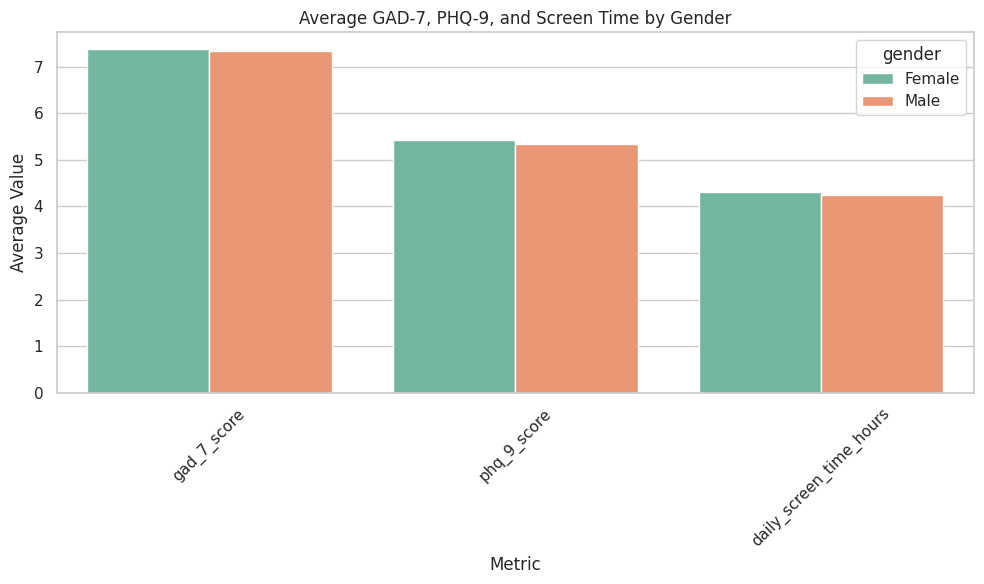

In [86]:

gender_means = df.groupby('gender')[['gad_7_score','phq_9_score','daily_screen_time_hours']].mean().reset_index()

gender_melted = gender_means.melt(id_vars='gender',
                                  var_name='Metric',
                                  value_name='Average')

plt.figure(figsize=(10,6))
sns.barplot(data=gender_melted, x='Metric', y='Average', hue='gender', palette='Set2')

plt.title("Average GAD-7, PHQ-9, and Screen Time by Gender")
plt.xlabel("Metric")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


The statistical summaries and visualizations highlight meaningful differences between genders in both mental health scores and social media behavior. Females show higher average daily screen time, along with slightly elevated PHQ‑9 and GAD‑7 scores compared to males. These patterns suggest that increased social media use may be associated with higher levels of anxiety and depression symptoms, particularly among female participants. The descriptive statistics also provide a strong overview of the dataset, showing the overall distribution and variability of key variables such as sleep duration, screen time, and mental health scores. Together, these findings offer a clearer understanding of how gender, screen time, and mental health indicators interact within the dataset.